In [1]:
import polars as pl

from datetime import date
import mplfinance as mpf

from ohlc_dss_model.data import load_parquet, remove_incomplete_days, intraday_session_tagging, session_tagging, filter_valid_sessions

from ohlc_dss_model.features import aggregate_sessions, yang_zhang, PRE_NY_SPEC, FULL_DAY_SPEC, assign_direction, calculate_excursion_bands

from ohlc_dss_model.utils import convert_to_timezone

from ohlc_dss_model import config

In [2]:
df = load_parquet()
df = convert_to_timezone(df)
df = session_tagging(df)
df = intraday_session_tagging(df)
df = remove_incomplete_days(df)

print(df.head(5))

shape: (5, 8)
┌──────────────────┬─────────┬─────────┬─────────┬─────────┬────────┬────────────┬─────────────────┐
│ DateTime         ┆ Open    ┆ High    ┆ Low     ┆ Close   ┆ Volume ┆ Session    ┆ Intraday_Sessio │
│ ---              ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---    ┆ ---        ┆ n               │
│ datetime[ns, Ame ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆ u64    ┆ date       ┆ ---             │
│ rica/New_York]   ┆         ┆         ┆         ┆         ┆        ┆            ┆ str             │
╞══════════════════╪═════════╪═════════╪═════════╪═════════╪════════╪════════════╪═════════════════╡
│ 2011-01-02       ┆ 2220.0  ┆ 2223.75 ┆ 2219.25 ┆ 2220.5  ┆ 889    ┆ 2011-01-03 ┆ Pre_Target_1    │
│ 18:00:00 EST     ┆         ┆         ┆         ┆         ┆        ┆            ┆                 │
│ 2011-01-02       ┆ 2220.0  ┆ 2222.0  ┆ 2219.75 ┆ 2221.5  ┆ 238    ┆ 2011-01-03 ┆ Pre_Target_1    │
│ 18:30:00 EST     ┆         ┆         ┆         ┆         ┆        ┆        

In [3]:
features = aggregate_sessions(df)
print(features.head(5))

shape: (5, 17)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Session   ┆ O_Pre_Tar ┆ O_Target_ ┆ O_Target_ ┆ … ┆ C_Pre_Tar ┆ C_Target_ ┆ C_Target_ ┆ C_Pre_Ta │
│ ---       ┆ get_1     ┆ 1         ┆ 2         ┆   ┆ get_1     ┆ 1         ┆ 2         ┆ rget_2   │
│ date      ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2011-01-0 ┆ 2220.0    ┆ 2239.5    ┆ 2258.25   ┆ … ┆ 2227.25   ┆ 2263.5    ┆ 2250.75   ┆ 2239.25  │
│ 3         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ 2011-01-0 ┆ 2251.25   ┆ 2257.0    ┆ 2242.0    ┆ … ┆ 2251.25   ┆ 2241.75   ┆ 2247.25   ┆ 2257.0   │
│ 4         ┆           ┆           ┆           ┆   ┆           ┆           

In [4]:
features = filter_valid_sessions(features)
print(features.select(["Session"]).tail(5))

shape: (5, 1)
┌────────────┐
│ Session    │
│ ---        │
│ date       │
╞════════════╡
│ 2026-04-10 │
│ 2026-04-13 │
│ 2026-04-14 │
│ 2026-04-15 │
│ 2026-04-16 │
└────────────┘


***

### **Defining Session Reference Open**
***
Reference open represents daily candle opening price and are defined as such:

$O_{Ref}$ (`O_Ref`) = `O_Asia` -> For each day

Every M level bands will be placed relative to this level.

In [5]:
features = features.with_columns(
    pl.col("O_Pre_Target_1").alias("O_Ref")
)
print(features.select(["Session", "O_Ref", "O_Pre_Target_1"]).head(3))

shape: (3, 3)
┌────────────┬─────────┬────────────────┐
│ Session    ┆ O_Ref   ┆ O_Pre_Target_1 │
│ ---        ┆ ---     ┆ ---            │
│ date       ┆ f64     ┆ f64            │
╞════════════╪═════════╪════════════════╡
│ 2011-01-03 ┆ 2220.0  ┆ 2220.0         │
│ 2011-01-04 ┆ 2251.25 ┆ 2251.25        │
│ 2011-01-05 ┆ 2245.75 ┆ 2245.75        │
└────────────┴─────────┴────────────────┘


***

### **Yang-Zhang Volatility**
***
We will be using Yang-Zhang volatility to help us predict the statistical levels, this levels will be used to capture intraday price movement.

You can use any volatility estimator but as previously stated in `02_feature_selection.ipynb` Yang-Zhang volatility fits our case the best

There will be 2 features we will be calculating with Yang-Zhang model:
- `Sigma_Historical`
- `Sigma_Today` (Pre NY movement as we don't want to leak NY data into the volatility model)

Yang-Zhang estimator are defined over $n$ trading days where each day $i$ has an overnight gap from the previous daily close $C_{i-1}$ to the open $O_i$:
$$\hat{\sigma}^2_{YZ} = \hat{\sigma}^2_o + k\,\hat{\sigma}^2_c + (1-k)\,\hat{\sigma}^2_{RS}$$

Where:

**Overnight Variance**:

$$\hat{\sigma}^2_o = \frac{1}{n-1} \sum_{i=1}^{n} \left( o_i - \bar{o} \right)^2
\quad \text{where} \quad
o_i = \ln\frac{O_i}{C_{i-1}}, \quad \bar{o} = \frac{1}{n}\sum_{i=1}^{n} o_i$$

**Open to Close Variance**:

$$\hat{\sigma}^2_c = \frac{1}{n-1} \sum_{i=1}^{n} \left( c_i - \bar{c} \right)^2
\quad \text{where} \quad
c_i = \ln\frac{C_i}{O_i}, \quad \bar{c} = \frac{1}{n}\sum_{i=1}^{n} c_i$$

**Rogers Satchell Variance**:

$$\hat{\sigma}^2_{RS} = \frac{1}{n} \sum_{i=1}^{n} \left[
    \ln\frac{H_i}{C_i}\ln\frac{H_i}{O_i} +
    \ln\frac{L_i}{C_i}\ln\frac{L_i}{O_i}
\right]$$

**Optimal Weight**:

$$k = \frac{0.34}{1.34 + \dfrac{n+1}{n-1}}$$

Note: $k$ is derived analytically and is not a tunable parameter, it depends only on $n$. Since it depends on $n$ `Sigma_Today` will not be needing $k$ as it is purely for today's pre NY volatility.

***
### **Sigma Historical (`sigma_historical`)**
Full OHLC including NY. Past days $d < t$ are fully resolved, using $C_{NY}(d)$ for a historical day is not leakage.

$$H^{full}(d) = \max(H_{Asia},\, H_{London},\, H_{NY}), \qquad L^{full}(d) = \min(L_{Asia},\, L_{London},\, L_{NY})$$

**Overnight Variance**:

$$\hat{\sigma}^2_o = \text{RollingVar}_N\!\left(\ln\frac{O_{Asia}(d)}{C_{NY}(d-1)}\right)$$

**Open to Close Variance**:

$$\hat{\sigma}^2_c = \text{RollingVar}_N\!\left(\ln\frac{C_{NY}(d)}{O_{Asia}(d)}\right)$$

**Rogers Satchell Variance**:

$$\hat{\sigma}^2_{RS} = \text{RollingMean}_N\!\left[\ln\frac{H^{full}}{C_{NY}}\ln\frac{H^{full}}{O_{Asia}} + \ln\frac{L^{full}}{C_{NY}}\ln\frac{L^{full}}{O_{Asia}}\right]$$

In [6]:
# Implementation for Yang Zhang estimator can be seen in `src/ohlc_dss_model/features/volatility.py`
features = yang_zhang(features, FULL_DAY_SPEC, mode="historical")
features = yang_zhang(features, PRE_NY_SPEC, mode="today")

print(features.select(["Session", "Sigma_Historical", "Sigma_Today"]).drop_nulls().head(5))

# should be n nulls as it needs n days burn in period
print(f"Null count historical: {features['Sigma_Historical'].null_count()}")

shape: (5, 3)
┌────────────┬──────────────────┬─────────────┐
│ Session    ┆ Sigma_Historical ┆ Sigma_Today │
│ ---        ┆ ---              ┆ ---         │
│ date       ┆ f64              ┆ f64         │
╞════════════╪══════════════════╪═════════════╡
│ 2011-01-12 ┆ 0.010045         ┆ 0.006469    │
│ 2011-01-13 ┆ 0.009763         ┆ 0.00226     │
│ 2011-01-14 ┆ 0.008417         ┆ 0.005013    │
│ 2011-01-18 ┆ 0.010128         ┆ 0.017422    │
│ 2011-01-19 ┆ 0.012248         ┆ 0.004482    │
└────────────┴──────────────────┴─────────────┘
Null count historical: 7


### **Volatility Adjusted Excursion Bands**
***

Intraday price behavior can be simplified into 2 components:
- Adverse Excursion (AE) -> Counter directional movement from reference open $O_{Ref}$
- Favorable Excursion (FE) -> Co directional move following adverse excursion

This framework estimates AE and FE magnitudes based on recent volatility and regime to construct symmetric price bands relative to reference open $O_{Ref}$. This bands are then used to capture Pre NY session interaction for downstream modelling.

***

### **Volatility Scaling**
Excursion prices are normalized using Yang Zhang volatility:
$$\varepsilon^*_{AE}(d) = \frac{\varepsilon_{AE}(d)}{\hat{\sigma}_{YZ}(d)}, \qquad \varepsilon^*_{FE}(d) = \frac{\varepsilon_{FE}(d)}{\hat{\sigma}_{YZ}(d)}$$

This produce stationary quantities such that it can be used across time.

***

### **Direction Definition**

Normalized daily candle body are defined as such:
$$z_{body}(d) = \frac{|{ln}(C_{NY}(d) / O_{Ref}(d))|}{\hat{\sigma}_{YZ}(d)}$$
let $\tau(d)$ be a volatility adaptive threshold:
$$z_{\sigma}(d) = \frac{\hat{\sigma}_{YZ}(d)}{{RollingMean}_{N}(\hat{\sigma}_{YZ}(d))}$$
$$\tau(d) = clip(\tau_0 * z_{\sigma}(d)^{-0.5}, \tau_{min}, \tau_{max})$$
Hence direction of a day is classified as such:
$${direction}(d) = \begin{cases}
{bullish} \qquad {z_{body}(d) > \tau(d) \land {C_{NY}(d)} > {O_{Asia}(d)}}\\
{bearish} \qquad {z_{body}(d) > \tau(d) \land {C_{NY}(d)} < {O_{Asia}(d)}}\\
{neutral} \qquad {z_{body}(d) \leq \tau(d)}
\end{cases}$$

Neutral here means day represents low volatility days
***

**Calculating $z_{body}(d)$**

In [7]:
directions = features.with_columns(
    ((pl.col("C_Pre_Target_2") / pl.col("O_Ref")).log().abs() / pl.col("Sigma_Historical")).alias("Z_Body")
)
print(directions.select(["Session", "Z_Body"]).drop_nulls().tail(3))

shape: (3, 2)
┌────────────┬──────────┐
│ Session    ┆ Z_Body   │
│ ---        ┆ ---      │
│ date       ┆ f64      │
╞════════════╪══════════╡
│ 2026-04-14 ┆ 0.253702 │
│ 2026-04-15 ┆ 0.022594 │
│ 2026-04-16 ┆ 0.159764 │
└────────────┴──────────┘


In [8]:
directions_clean = directions.filter(
    pl.col("Z_Body").is_finite() &
    pl.col("Z_Body").is_not_null() &
    pl.col("Sigma_Historical").is_not_null()
)
directions_clean.select(pl.col("Z_Body")).describe()

statistic,Z_Body
str,f64
"""count""",3760.0
"""null_count""",0.0
"""mean""",0.258629
"""std""",0.228199
"""min""",0.0
"""25%""",0.09686
"""50%""",0.201844
"""75%""",0.360577
"""max""",2.427973


With this values we can emphirically derive threshold parameters:
- $\tau_0$ -> Set to 75th percentile ($z_{body} = 1.11$), such that only upper quartile moves classifies as directional.
- $\tau_{min}$ -> Set to 25th percentile ($z_{body} = 0.26$), to prevent over sensitivity in high volatility regimes.
- $\tau_{max}$ -> Caps the upper tail to prevent the threshold from being too strict. ($z_{body} = 1.75$)

These parameters may be adjusted.
***

**Calculating $z_{\sigma}(d)$**

In [9]:
directions = directions.with_columns(
    (pl.col("Sigma_Historical") / pl.col("Sigma_Historical").rolling_mean(20)).alias("Z_Sigma")
)

In [10]:
print(directions.select(["Z_Sigma"]).drop_nulls().describe())

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ Z_Sigma  │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 3741.0   │
│ null_count ┆ 0.0      │
│ mean       ┆ 1.017334 │
│ std        ┆ 0.319194 │
│ min        ┆ 0.364366 │
│ 25%        ┆ 0.796679 │
│ 50%        ┆ 0.969087 │
│ 75%        ┆ 1.179473 │
│ max        ┆ 2.854755 │
└────────────┴──────────┘


***

**Calculating $\tau(d)$**

In [11]:
# As we discover earlier here are the threshold parameters
tau_0 = 1.11
tau_min = 0.26
tau_max = 1.75

In [12]:
directions = directions.with_columns(
    (tau_0 * (pl.col("Z_Sigma") ** -0.5)).clip(tau_min, tau_max).alias("Tau")
)

In [13]:
print(directions.select(["Session", "Tau", "Z_Body"]).drop_nulls().tail(5))

shape: (5, 3)
┌────────────┬──────────┬──────────┐
│ Session    ┆ Tau      ┆ Z_Body   │
│ ---        ┆ ---      ┆ ---      │
│ date       ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╡
│ 2026-04-10 ┆ 1.245901 ┆ 0.249094 │
│ 2026-04-13 ┆ 1.176364 ┆ 0.329519 │
│ 2026-04-14 ┆ 1.147112 ┆ 0.253702 │
│ 2026-04-15 ┆ 1.144415 ┆ 0.022594 │
│ 2026-04-16 ┆ 1.153756 ┆ 0.159764 │
└────────────┴──────────┴──────────┘


***

**Deriving $direction(d)$**

In [14]:
directions = directions.with_columns(
    pl.when((pl.col("Z_Body") > pl.col("Tau")) & (pl.col("C_Target_2") > pl.col("O_Ref")))
    .then(pl.lit("bullish"))
    .when((pl.col("Z_Body") > pl.col("Tau")) & (pl.col("C_Target_2") < pl.col("O_Ref")))
    .then(pl.lit("bearish"))
    .otherwise(pl.lit("neutral")).alias("Direction")
)

In [15]:
print(directions.select(["Session", "Direction"]).drop_nulls().tail(5))

shape: (5, 2)
┌────────────┬───────────┐
│ Session    ┆ Direction │
│ ---        ┆ ---       │
│ date       ┆ str       │
╞════════════╪═══════════╡
│ 2026-04-10 ┆ neutral   │
│ 2026-04-13 ┆ neutral   │
│ 2026-04-14 ┆ neutral   │
│ 2026-04-15 ┆ neutral   │
│ 2026-04-16 ┆ neutral   │
└────────────┴───────────┘


In [16]:
print(directions["Direction"].value_counts())

shape: (3, 2)
┌───────────┬───────┐
│ Direction ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ bullish   ┆ 13    │
│ neutral   ┆ 3735  │
│ bearish   ┆ 19    │
└───────────┴───────┘


In practice, the parameter of $\tau(d) = 1.11$ is way too strict hence there is less directional classes, hence it would be wise to lower $\tau(d)$ as we would only want to assign neutral to exceptionally small body indicating a neutral day where your usual close to open comparison wouldnt be valid, this way we want to aim somewhere between 25th quantile and 50th quantile.

> Note to researcher, we need to later find the optimal threshold through more thorough testing and benchmark

In [17]:
# with tau = 0.4
directions_04 = assign_direction(features)
directions_04= directions_04.drop_nulls()
print(directions_04["Direction"].value_counts())

shape: (3, 2)
┌───────────┬───────┐
│ Direction ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ bearish   ┆ 839   │
│ bullish   ┆ 1171  │
│ neutral   ┆ 1743  │
└───────────┴───────┘


In [18]:
directions_04.select(["Session", "Direction"]).tail(5)

Session,Direction
date,str
2026-04-10,"""neutral"""
2026-04-13,"""bullish"""
2026-04-14,"""bullish"""
2026-04-15,"""bullish"""
2026-04-16,"""neutral"""


***

### **Excursion Decomposition**
Each day are decomposed into two components relative to $O_{Ref}$:

**Adverse Excursion (AE)**
$$\varepsilon_{AE}(d) = \begin{cases}
O_{Ref}(d) - L_{Day}(d) & \text{bullish}\\
H_{Day}(d) - O_{Ref}(d) & \text{bearish}\\
\max(O_{Ref}(d) - L_{Day}(d),\ H_{Day}(d) - O_{Ref}(d)) & \text{neutral}
\end{cases}$$

**Favorable Excursion (FE)**
$$\varepsilon_{FE}(d) = \begin{cases}
H_{Day}(d) - O_{Ref}(d) & \text{bullish}\\
O_{Ref}(d) - L_{Day}(d) & \text{bearish}\\
\max(O_{Ref}(d) - L_{Day}(d),\ H_{Day}(d) - O_{Ref}(d)) & \text{neutral}
\end{cases}$$

Where:
$$L_{Day} = min(L_{Asia}, L_{London}, L_{NY})$$
$$H_{Day} = max(M_{Asia}, M_{London}, M_{NY})$$
***

**Calculating $L_{Day}$ and $H_{Day}$**

In [19]:
excursions = assign_direction(features)
excursions = excursions.with_columns([
    pl.min_horizontal(pl.col("L_Pre_Target_1"), pl.col("L_Pre_Target_2"), pl.col("L_Target_1"), pl.col("L_Target_2")).alias("L_Day"),
    pl.max_horizontal(pl.col("H_Pre_Target_1"), pl.col("H_Pre_Target_2"), pl.col("H_Target_1"), pl.col("H_Target_2")).alias("H_Day")
]) 
print(excursions.drop_nulls().select(["Session", "L_Day", "H_Day"]).head(5))

shape: (5, 3)
┌────────────┬─────────┬─────────┐
│ Session    ┆ L_Day   ┆ H_Day   │
│ ---        ┆ ---     ┆ ---     │
│ date       ┆ f64     ┆ f64     │
╞════════════╪═════════╪═════════╡
│ 2011-01-24 ┆ 2264.5  ┆ 2300.75 │
│ 2011-01-25 ┆ 2281.25 ┆ 2303.25 │
│ 2011-01-26 ┆ 2298.0  ┆ 2320.0  │
│ 2011-01-27 ┆ 2313.25 ┆ 2334.5  │
│ 2011-01-28 ┆ 2263.0  ┆ 2331.0  │
└────────────┴─────────┴─────────┘


**Calculating $\varepsilon_{AE}(d)$ and $\varepsilon_{FE}(d)$**

In [20]:
excursions = excursions.with_columns([
    (
        pl.when(pl.col("Direction") == "bullish")
        .then(pl.col("O_Ref") - pl.col("L_Day"))
        .when(pl.col("Direction") == "bearish")
        .then(pl.col("H_Day") - pl.col("O_Ref"))
        .otherwise(pl.max_horizontal(pl.col("H_Day") - pl.col("O_Ref"), pl.col("O_Ref") - pl.col("L_Day")))
    ).alias("_epsilon_ae"),
    (
        pl.when(pl.col("Direction") == "bullish")
        .then(pl.col("H_Day") - pl.col("O_Ref"))
        .when(pl.col("Direction") == "bearish")
        .then(pl.col("O_Ref") - pl.col("L_Day"))
        .otherwise(pl.max_horizontal(pl.col("H_Day") - pl.col("O_Ref"), pl.col("O_Ref") - pl.col("L_Day")))
    ).alias("_epsilon_fe")
])

print(excursions.drop_nulls().select(["Session", "Direction", "_epsilon_ae", "_epsilon_fe"]).head(5))

shape: (5, 4)
┌────────────┬───────────┬─────────────┬─────────────┐
│ Session    ┆ Direction ┆ _epsilon_ae ┆ _epsilon_fe │
│ ---        ┆ ---       ┆ ---         ┆ ---         │
│ date       ┆ str       ┆ f64         ┆ f64         │
╞════════════╪═══════════╪═════════════╪═════════════╡
│ 2011-01-24 ┆ bullish   ┆ 4.25        ┆ 32.0        │
│ 2011-01-25 ┆ neutral   ┆ 15.5        ┆ 15.5        │
│ 2011-01-26 ┆ bullish   ┆ 2.5         ┆ 19.5        │
│ 2011-01-27 ┆ neutral   ┆ 17.75       ┆ 17.75       │
│ 2011-01-28 ┆ bearish   ┆ 9.25        ┆ 58.75       │
└────────────┴───────────┴─────────────┴─────────────┘


***

### **Volatility Normalization**
Excursions are normalized with Yang Zhang volatility:
$$\varepsilon^*_{AE}(d) = \frac{\varepsilon_{AE}(d)}{\hat{\sigma}_{YZ}(d)}, \quad 
\varepsilon^*_{FE}(d) = \frac{\varepsilon_{FE}(d)}{\hat{\sigma}_{YZ}(d)}$$
***
### **Expected Excursion**
Expected normalized adverse / favorable excursions:
$$\mu^*_{AE}(t) = \frac{1}{N} \sum_{d=t-N}^{t-1} \varepsilon^*_{AE}(d), \qquad
\mu^*_{FE}(t) = \frac{1}{N} \sum_{d=t-N}^{t-1} \varepsilon^*_{FE}(d),
$$

One period shift to avoid forward looking bias

We then scale them to current volatility environment:
$$\hat{\mu}_{AE}(t) = \hat{\mu}^*_{AE}(t) \cdot \hat\sigma_{YZ}(t-1), \qquad
\hat{\mu}_{FE}(t) = \hat{\mu}^*_{FE}(t) \cdot \hat\sigma_{YZ}(t-1)$$
***
### **Excursion Band Construction**
Symmetric bands are place relative and around reference open:
$$B^{\pm}_{AE}(t) = O_{Ref}(t) \pm \hat{\mu}_{AE}(t)$$
$$B^{\pm}_{FE}(t) = O_{Ref}(t) \pm \hat{\mu}_{FE}(t)$$
Hence this defined the expected adverse / favorable excursion zones
***

### **Volatility Scaled Band Areas**
To help with stochastic price behavior and reduce false precision, each band is expanded into a volatility scaled areas.

Hence a band width is defined as:
$$\Delta(t) = k \cdot \hat{\sigma}_{YZ}(t-1) \cdot O_{Ref}(t)$$
Where:
- k is a scaling constant

So now each bands becomes an interval:
$$\tilde{B}(t) = [B(t) - \Delta(t), B(t) + \Delta(t)]$$
Applied to all bands:
$$B^{\pm}_{AE}(t) - \Delta(t), B^{\pm}_{AE}(t) + \Delta(t)$$
$$B^{\pm}_{FE}(t) - \Delta(t), B^{\pm}_{FE}(t) + \Delta(t)$$
***

**Calculating $\varepsilon^*_{AE}(d), \quad \varepsilon^*_{FE}(d)$**

In [21]:
excursions = excursions.with_columns([
    (pl.col("_epsilon_ae") / pl.col("Sigma_Historical")).alias("_epsilon_ae_normalized"),
    (pl.col("_epsilon_fe") / pl.col("Sigma_Historical")).alias("_epsilon_fe_normalized")
])
print(excursions.drop_nulls().select(["Session", "_epsilon_ae_normalized", "_epsilon_fe_normalized"]).head(5))

shape: (5, 3)
┌────────────┬────────────────────────┬────────────────────────┐
│ Session    ┆ _epsilon_ae_normalized ┆ _epsilon_fe_normalized │
│ ---        ┆ ---                    ┆ ---                    │
│ date       ┆ f64                    ┆ f64                    │
╞════════════╪════════════════════════╪════════════════════════╡
│ 2011-01-24 ┆ 276.042081             ┆ 2078.434496            │
│ 2011-01-25 ┆ 948.009804             ┆ 948.009804             │
│ 2011-01-26 ┆ 151.996856             ┆ 1185.575474            │
│ 2011-01-27 ┆ 1196.435748            ┆ 1196.435748            │
│ 2011-01-28 ┆ 586.256433             ┆ 3723.520586            │
└────────────┴────────────────────────┴────────────────────────┘


**Calculating $\mu^*_{AE}(t), \quad \mu^*_{FE}(t)$**

In [22]:
excursions = excursions.with_columns([
    (pl.col("_epsilon_ae_normalized").shift(1).rolling_mean(20)).alias("_mu_ae"),
    (pl.col("_epsilon_fe_normalized").shift(1).rolling_mean(20)).alias("_mu_fe")
])
print(excursions.drop_nulls().select(["Session", "_mu_ae", "_mu_fe"]).head(5))

shape: (5, 3)
┌────────────┬─────────────┬─────────────┐
│ Session    ┆ _mu_ae      ┆ _mu_fe      │
│ ---        ┆ ---         ┆ ---         │
│ date       ┆ f64         ┆ f64         │
╞════════════╪═════════════╪═════════════╡
│ 2011-02-10 ┆ 1277.471275 ┆ 1774.681807 │
│ 2011-02-11 ┆ 1255.966622 ┆ 1753.177154 │
│ 2011-02-14 ┆ 1268.805888 ┆ 1868.688668 │
│ 2011-02-15 ┆ 1260.90892  ┆ 1860.7917   │
│ 2011-02-16 ┆ 1042.610936 ┆ 1642.493716 │
└────────────┴─────────────┴─────────────┘


**Calculating $\hat{\mu}_{AE}(t), \quad \hat{\mu}_{FE}(t)$**

In [23]:
excursions = excursions.with_columns([
    (pl.col("_mu_ae") * pl.col("Sigma_Historical").shift(1)).alias("_mu_ae_scaled"),
    (pl.col("_mu_fe") * pl.col("Sigma_Historical").shift(1)).alias("_mu_fe_scaled")
])
print(excursions.drop_nulls().select(["Session", "_mu_ae_scaled", "_mu_fe_scaled"]).head(5))

shape: (5, 3)
┌────────────┬───────────────┬───────────────┐
│ Session    ┆ _mu_ae_scaled ┆ _mu_fe_scaled │
│ ---        ┆ ---           ┆ ---           │
│ date       ┆ f64           ┆ f64           │
╞════════════╪═══════════════╪═══════════════╡
│ 2011-02-10 ┆ 12.289281     ┆ 17.07245      │
│ 2011-02-11 ┆ 10.432653     ┆ 14.562719     │
│ 2011-02-14 ┆ 10.658626     ┆ 15.697951     │
│ 2011-02-15 ┆ 10.003593     ┆ 14.762845     │
│ 2011-02-16 ┆ 8.159154      ┆ 12.853653     │
└────────────┴───────────────┴───────────────┘


**Calculating $B^{\pm}_{AE}(t), \quad B^{\pm}_{FE}(t)$**

In [24]:
excursions = excursions.with_columns([
    (pl.col("O_Ref") + pl.col("_mu_ae_scaled")).alias("_band_AE_Pos"),
    (pl.col("O_Ref") - pl.col("_mu_ae_scaled")).alias("_band_AE_Neg"),
    (pl.col("O_Ref") + pl.col("_mu_fe_scaled")).alias("_band_FE_Pos"),
    (pl.col("O_Ref") - pl.col("_mu_fe_scaled")).alias("_band_FE_Neg")
])
print(excursions.drop_nulls().select(["Session", "_band_AE_Pos", "_band_AE_Neg", "_band_FE_Pos", "_band_FE_Neg"]).head(5))

shape: (5, 5)
┌────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ Session    ┆ _band_AE_Pos ┆ _band_AE_Neg ┆ _band_FE_Pos ┆ _band_FE_Neg │
│ ---        ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│ date       ┆ f64          ┆ f64          ┆ f64          ┆ f64          │
╞════════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 2011-02-10 ┆ 2363.039281  ┆ 2338.460719  ┆ 2367.82245   ┆ 2333.67755   │
│ 2011-02-11 ┆ 2365.932653  ┆ 2345.067347  ┆ 2370.062719  ┆ 2340.937281  │
│ 2011-02-14 ┆ 2386.908626  ┆ 2365.591374  ┆ 2391.947951  ┆ 2360.552049  │
│ 2011-02-15 ┆ 2388.503593  ┆ 2368.496407  ┆ 2393.262845  ┆ 2363.737155  │
│ 2011-02-16 ┆ 2388.909154  ┆ 2372.590846  ┆ 2393.603653  ┆ 2367.896347  │
└────────────┴──────────────┴──────────────┴──────────────┴──────────────┘


In [25]:
print(excursions.columns)

['Session', 'O_Pre_Target_1', 'O_Target_1', 'O_Target_2', 'O_Pre_Target_2', 'H_Pre_Target_1', 'H_Target_1', 'H_Target_2', 'H_Pre_Target_2', 'L_Pre_Target_1', 'L_Target_1', 'L_Target_2', 'L_Pre_Target_2', 'C_Pre_Target_1', 'C_Target_1', 'C_Target_2', 'C_Pre_Target_2', 'O_Ref', 'Sigma_Historical', 'Sigma_Today', 'Z_Body', 'Z_Sigma', 'Tau', 'Direction', 'L_Day', 'H_Day', '_epsilon_ae', '_epsilon_fe', '_epsilon_ae_normalized', '_epsilon_fe_normalized', '_mu_ae', '_mu_fe', '_mu_ae_scaled', '_mu_fe_scaled', '_band_AE_Pos', '_band_AE_Neg', '_band_FE_Pos', '_band_FE_Neg']


**Calculating $\Delta(t)$**

In [26]:
band_k = 0.2 # Just a placeholder can be optimized later
excursions = excursions.with_columns([
    (band_k * pl.col("Sigma_Historical").shift(1) * pl.col("Z_Sigma").shift(1) * pl.col("O_Ref")).alias("_delta_t")
])

**Calculating $\tilde{B}(t)$**

In [27]:
excursions = excursions.with_columns([
    (pl.col("_band_AE_Neg") + pl.col("_delta_t")).alias("Band_AE_Neg_Upper"),
    (pl.col("_band_AE_Neg") - pl.col("_delta_t")).alias("Band_AE_Neg_Lower"),
    (pl.col("_band_AE_Pos") + pl.col("_delta_t")).alias("Band_AE_Pos_Upper"),
    (pl.col("_band_AE_Pos") - pl.col("_delta_t")).alias("Band_AE_Pos_Lower"),
    (pl.col("_band_FE_Neg") + pl.col("_delta_t")).alias("Band_FE_Neg_Upper"),
    (pl.col("_band_FE_Neg") - pl.col("_delta_t")).alias("Band_FE_Neg_Lower"),
    (pl.col("_band_FE_Pos") + pl.col("_delta_t")).alias("Band_FE_Pos_Upper"),
    (pl.col("_band_FE_Pos") - pl.col("_delta_t")).alias("Band_FE_Pos_Lower")
])

In [28]:
features = calculate_excursion_bands(features)
print(features.drop_nulls().select([
    "Session", 
    "Band_AE_Pos_Upper", "Band_AE_Pos_Lower", 
    "Band_AE_Neg_Upper", "Band_AE_Neg_Lower",
    "Band_FE_Pos_Upper", "Band_FE_Pos_Lower",
    "Band_FE_Neg_Upper", "Band_FE_Neg_Lower"
]).head(5))
print(features.columns)

shape: (5, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Session   ┆ Band_AE_P ┆ Band_AE_P ┆ Band_AE_N ┆ … ┆ Band_FE_P ┆ Band_FE_P ┆ Band_FE_N ┆ Band_FE_ │
│ ---       ┆ os_Upper  ┆ os_Lower  ┆ eg_Upper  ┆   ┆ os_Upper  ┆ os_Lower  ┆ eg_Upper  ┆ Neg_Lowe │
│ date      ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ r        │
│           ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2011-01-2 ┆ 2304.7565 ┆ 2298.2838 ┆ 2239.2161 ┆ … ┆ 2304.7565 ┆ 2298.2838 ┆ 2239.2161 ┆ 2232.743 │
│ 4         ┆ 29        ┆ 1         ┆ 9         ┆   ┆ 29        ┆ 1         ┆ 9         ┆ 471      │
│ 2011-01-2 ┆ 2331.6092 ┆ 2324.5369 ┆ 2268.9630 ┆ … ┆ 2335.5734 ┆ 2328.5012 ┆

In [29]:
print(features.select(["Band_AE_Pos_Center", "Band_AE_Neg_Center", "Band_FE_Pos_Center", "Band_FE_Neg_Center"]).drop_nulls().head(5))

shape: (5, 4)
┌────────────────────┬────────────────────┬────────────────────┬────────────────────┐
│ Band_AE_Pos_Center ┆ Band_AE_Neg_Center ┆ Band_FE_Pos_Center ┆ Band_FE_Neg_Center │
│ ---                ┆ ---                ┆ ---                ┆ ---                │
│ f64                ┆ f64                ┆ f64                ┆ f64                │
╞════════════════════╪════════════════════╪════════════════════╪════════════════════╡
│ 2301.52017         ┆ 2235.97983         ┆ 2301.52017         ┆ 2235.97983         │
│ 2328.073087        ┆ 2265.426913        ┆ 2332.037372        ┆ 2261.462628        │
│ 2334.422858        ┆ 2266.577142        ┆ 2338.632743        ┆ 2262.367257        │
│ 2347.603708        ┆ 2285.896292        ┆ 2354.267311        ┆ 2279.232689        │
│ 2340.763506        ┆ 2302.736494        ┆ 2346.774035        ┆ 2296.725965        │
└────────────────────┴────────────────────┴────────────────────┴────────────────────┘


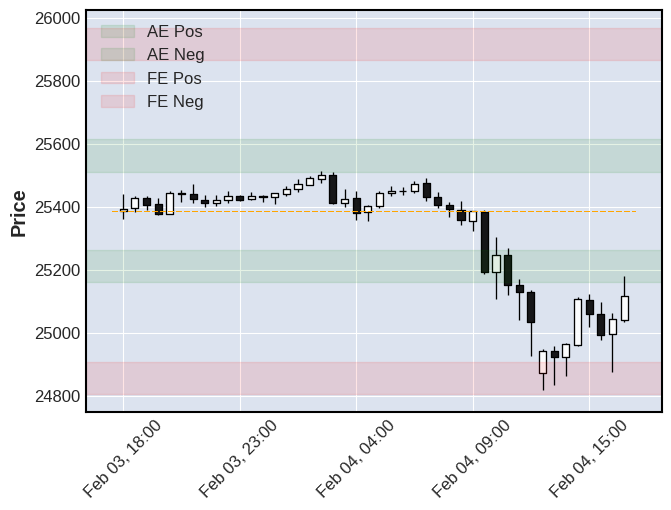

In [30]:
excursion_plot = df.filter(pl.col("Session") == date(2026, 2, 4)).to_pandas()
excursion_plot = excursion_plot.set_index("DateTime")
excursion_bands = features.filter(pl.col("Session") == date(2026, 2, 4)).select([
    "Band_AE_Pos_Upper", "Band_AE_Pos_Lower",
    "Band_AE_Neg_Upper", "Band_AE_Neg_Lower",
    "Band_FE_Pos_Upper", "Band_FE_Pos_Lower",
    "Band_FE_Neg_Upper", "Band_FE_Neg_Lower",
    "O_Ref"
]).to_pandas()

bands = excursion_bands.iloc[0]

fig, axes = mpf.plot(
    excursion_plot,
    type="candle",
    returnfig=True,
    hlines=dict(
        hlines=[bands["O_Ref"]],
        colors=["orange"],
        linestyle="--",
        linewidths=1
    )
)

ax = axes[0]
ax.axhspan(bands["Band_AE_Pos_Lower"], bands["Band_AE_Pos_Upper"], alpha=0.1, color="green", label="AE Pos")
ax.axhspan(bands["Band_AE_Neg_Lower"], bands["Band_AE_Neg_Upper"], alpha=0.1, color="green", label="AE Neg")
ax.axhspan(bands["Band_FE_Pos_Lower"], bands["Band_FE_Pos_Upper"], alpha=0.1, color="red", label="FE Pos")
ax.axhspan(bands["Band_FE_Neg_Lower"], bands["Band_FE_Neg_Upper"], alpha=0.1, color="red", label="FE Neg")
ax.legend(loc="upper left")

mpf.show()

***